In [552]:
import os
from pyspark.sql.functions import count, col, when, broadcast, udf, pandas_udf, rand, monotonically_increasing_id
from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer, PCA, StandardScalerModel, PCAModel
from pyspark.ml.clustering import KMeans, KMeansModel
from sklearn.manifold import TSNE
from pyspark.ml.linalg import Vectors, VectorUDT
from pyspark.sql import SparkSession
from pyspark.sql.types import StringType, BooleanType, DoubleType, ArrayType, IntegerType, StructType, StructField, FloatType
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, Draw
from pyspark.ml.evaluation import ClusteringEvaluator
from transformers import AutoTokenizer, AutoModel
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from rdkit.Chem import rdMolDescriptors
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, roc_curve, roc_auc_score
import umap
from tqdm import tqdm
import torch
import datamol as dm
from rdkit import Chem
from collections import Counter
from rdkit.Chem import AllChem
import lightgbm as lgb
import pandas as pd
import numpy as np
import logging
import matplotlib.pyplot as plt
from rdkit.Chem import DataStructs
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator, AdditionalOutput
from rdkit.Chem import rdFingerprintGenerator
import seaborn as sns
import findspark
import os
import sys
import pickle
import random

import functions
import importlib
importlib.reload(functions)
from functions import *


In [ ]:
spark.stop()

In [2]:
findspark.init()


In [3]:
spark = SparkSession.builder\
    .appName("Molecule Analysis")\
    .config("spark.executor.memory", "22g")\
    .config("spark.driver.memory", "16g")\
    .config("spark.memory.fraction", "0.7")\
    .config("spark.memory.storageFraction", "0.4")\
    .config("spark.network.timeout", "1200s")\
    .config("spark.executor.heartbeatInterval", "200s")\
    .config("spark.sql.broadcastTimeout", "1500s")\
    .config("spark.sql.shuffle.partitions", "200") \
    .getOrCreate()


25/02/10 19:25:18 WARN Utils: Your hostname, user-ThinkPad-E15-Gen-2 resolves to a loopback address: 127.0.1.1; using 10.202.33.187 instead (on interface wlp0s20f3)
25/02/10 19:25:18 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/02/10 19:25:18 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [589]:
filename = "leash-BELKA/train.parquet"
data = spark.read.parquet(filename)

data.printSchema()

data.show(5)

root
 |-- id: long (nullable = true)
 |-- buildingblock1_smiles: string (nullable = true)
 |-- buildingblock2_smiles: string (nullable = true)
 |-- buildingblock3_smiles: string (nullable = true)
 |-- molecule_smiles: string (nullable = true)
 |-- protein_name: string (nullable = true)
 |-- binds: long (nullable = true)

+---+---------------------+---------------------+---------------------+--------------------+------------+-----+
| id|buildingblock1_smiles|buildingblock2_smiles|buildingblock3_smiles|     molecule_smiles|protein_name|binds|
+---+---------------------+---------------------+---------------------+--------------------+------------+-----+
|  0| C#CC[C@@H](CC(=O)...| C#CCOc1ccc(CN)cc1.Cl| Br.Br.NCC1CCCN1c1...|C#CCOc1ccc(CNc2nc...|        BRD4|    0|
|  1| C#CC[C@@H](CC(=O)...| C#CCOc1ccc(CN)cc1.Cl| Br.Br.NCC1CCCN1c1...|C#CCOc1ccc(CNc2nc...|         HSA|    0|
|  2| C#CC[C@@H](CC(=O)...| C#CCOc1ccc(CN)cc1.Cl| Br.Br.NCC1CCCN1c1...|C#CCOc1ccc(CNc2nc...|         sEH|    0|
|  3|

In [7]:
data = data.filter(col("protein_name") == "sEH")

counts = data.groupBy("binds").count().collect()
counts_dict = {row['binds']: row['count'] for row in counts}

count_binds_1 = counts_dict.get(1, 0)
count_binds_0 = counts_dict.get(0, 0)

total_counts = count_binds_1 + count_binds_0
ratio_binds_0 = count_binds_1 / total_counts
ratio_binds_1 = count_binds_1 / total_counts

binds_1 = int(100000 * ratio_binds_1)
binds_0 = 100000-binds_1

binds_1_sampled = data.filter(col("binds") == 1).orderBy(rand()).limit(binds_1)
binds_0_sampled = data.filter(col("binds") == 0).orderBy(rand()).limit(binds_0)

sampled_data = binds_0_sampled.union(binds_1_sampled)

sampled_data.groupBy("binds").count().show()

+-----+-----+
|binds|count|
+-----+-----+
|    0|99264|
|    1|  736|
+-----+-----+



In [17]:
desc_schema = StructType([
    StructField("mol_wt", DoubleType(), True),
    StructField("mol_logp", DoubleType(), True),
    StructField("tpsa", DoubleType(), True),
]
)

@pandas_udf(desc_schema)
def calculate_desc(smiles_series: pd.Series) -> pd.DataFrame:

    mols = smiles_series.apply(Chem.MolFromSmiles)
    
    mw = mols.apply(lambda mol: round(Descriptors.MolWt(mol), 3) if mol else None)
    logp = mols.apply(lambda mol: round(Descriptors.MolLogP(mol), 3) if mol else None)
    tpsa = mols.apply(lambda mol: round(Descriptors.TPSA(mol), 3) if mol else None)


    return pd.DataFrame({'mol_wt': mw, 'mol_logp': logp, 'tpsa': tpsa})
    
sampled_data_with_desc = sampled_data.withColumn("molecule", calculate_desc(col("molecule_smiles")))
sampled_data_with_desc = sampled_data_with_desc.withColumn("block1", calculate_desc(col("buildingblock1_smiles")))
sampled_data_with_desc = sampled_data_with_desc.withColumn("block2", calculate_desc(col("buildingblock2_smiles")))
sampled_data_with_desc = sampled_data_with_desc.withColumn("block3", calculate_desc(col("buildingblock3_smiles")))

In [18]:
selected_columns = [
    "id",
    col("molecule.mol_wt").alias("molecule_mol_wt"),
    col("molecule.mol_logp").alias("molecule_mol_logp"),
    col("molecule.tpsa").alias("molecule_tpsa"),
    col("block1.mol_wt").alias("block1_mol_wt"),
    col("block1.mol_logp").alias("block1_mol_logp"),
    col("block1.tpsa").alias("block1_tpsa"),
    col("block2.mol_wt").alias("block2_mol_wt"),
    col("block2.mol_logp").alias("block2_mol_logp"),
    col("block2.tpsa").alias("block2_tpsa"),
    col("block3.mol_wt").alias("block3_mol_wt"),
    col("block3.mol_logp").alias("block3_mol_logp"),
    col("block3.tpsa").alias("block3_tpsa"),
    "binds"
]

flattened_data = sampled_data_with_desc.select(*selected_columns)

In [19]:
desc_columns = [col_name for col_name in flattened_data.columns if col_name != "id" and col_name != "binds"]

assembler = VectorAssembler(inputCols=desc_columns, outputCol="features")
sampled_data_with_features = assembler.transform(flattened_data).select("id", "binds", "features")

In [21]:
scaler = StandardScaler(inputCol="features", outputCol="scaled_features", withStd=True, withMean=True)
scaler_model = scaler.fit(sampled_data_with_features)
scaled_data = scaler_model.transform(sampled_data_with_features).select("id", "binds", "scaled_features")

In [22]:
scaler_model.write().overwrite().save("./intermediates/scaler_model")

In [9]:
scaler_model = StandardScalerModel.load("./intermediates/scaler_model")
scaled_data = scaler_model.transform(sampled_data_with_features)

In [68]:
pca = PCA(k=8, inputCol="scaled_features", outputCol="pca_features")
pca_model = pca.fit(scaled_data)
reduced_data = pca_model.transform(scaled_data).select("id", "binds", "pca_features")

In [69]:
pca_model.write().overwrite().save("./intermediates/pca_model")

In [10]:
pca_model = PCAModel.load("./intermediates/pca_model")
reduced_data = pca_model.transform(scaled_data).select("id", "binds", "pca_features")

In [13]:
kmeans = KMeans(k = 30, seed = 42, maxIter = 10, featuresCol = 'pca_features', predictionCol = 'kmeans_cluster')
k_means_model = kmeans.fit(reduced_data)
kmeans_clusters = k_means_model.transform(reduced_data).select("id", "binds", "kmeans_cluster")

In [ ]:
k_means_model.write().overwrite().save("./intermediates/k_means_model")

In [11]:
k_means_model = KMeansModel.load("./intermediates/k_means_model")
kmeans_clusters = k_means_model.transform(reduced_data).select("id", "binds", "kmeans_cluster")
kmeans_clusters.write.save("./intermediates/kmeans_clusters", format="parquet", mode='overwrite')

In [25]:
kmeans_clusters = spark.read.parquet("./intermediates/kmeans_clusters")

In [34]:
all_clustered_data = kmeans_clusters

for i in range(5):
    
    data = data.filter(col("protein_name") == "sEH")

    counts = data.groupBy("binds").count().collect()
    counts_dict = {row['binds']: row['count'] for row in counts}

    count_binds_1 = counts_dict.get(1, 0)
    count_binds_0 = counts_dict.get(0, 0)

    total_counts = count_binds_1 + count_binds_0
    ratio_binds_0 = count_binds_1 / total_counts
    ratio_binds_1 = count_binds_1 / total_counts

    binds_1 = int(100000 * ratio_binds_1)
    binds_0 = 100000-binds_1

    binds_1_sampled = data.filter(col("binds") == 1).orderBy(rand()).limit(binds_1)
    binds_0_sampled = data.filter(col("binds") == 0).orderBy(rand()).limit(binds_0)

    sampled_data = binds_0_sampled.union(binds_1_sampled)

    sampled_data_with_desc = sampled_data.withColumn("molecule", calculate_desc(col("molecule_smiles")))
    sampled_data_with_desc = sampled_data_with_desc.withColumn("block1", calculate_desc(col("buildingblock1_smiles")))
    sampled_data_with_desc = sampled_data_with_desc.withColumn("block2", calculate_desc(col("buildingblock2_smiles")))
    sampled_data_with_desc = sampled_data_with_desc.withColumn("block3", calculate_desc(col("buildingblock3_smiles")))
    flattened_data = sampled_data_with_desc.select(*selected_columns)
    desc_columns = [col_name for col_name in flattened_data.columns if col_name != "id" and col_name != "binds"]

    assembler = VectorAssembler(inputCols=desc_columns, outputCol="features")
    sampled_data_with_features = assembler.transform(flattened_data).select("id", "binds", "features")

    scaler_model = StandardScalerModel.load("./intermediates/scaler_model")
    scaled_data = scaler_model.transform(sampled_data_with_features).select("id", "binds", "scaled_features")

    pca_model = PCAModel.load("./intermediates/pca_model")
    reduced_data = pca_model.transform(scaled_data).select("id", "binds", "pca_features")

    k_means_model = KMeansModel.load("./intermediates/k_means_model")
    new_kmeans_clusters = k_means_model.transform(reduced_data).select("id", "binds", "kmeans_cluster")

    all_clustered_data = all_clustered_data.union(new_kmeans_clusters)


In [35]:
all_clustered_data.write.save("./intermediates/all_clustered_data", format="parquet", mode='overwrite')

In [36]:
all_clustered_data.printSchema()

root
 |-- id: long (nullable = true)
 |-- binds: long (nullable = true)
 |-- kmeans_cluster: integer (nullable = true)



In [37]:
all_clustered_data = spark.read.parquet("./intermediates/all_clustered_data")

In [38]:
binds1 = all_clustered_data.filter(col("binds") == 1)
binds0 = all_clustered_data.filter(col("binds") == 0)

In [39]:
binds_1_counts = binds1.groupBy("kmeans_cluster").count().withColumnRenamed("count", "count_binds_1")
binds_0_counts = binds0.groupBy("kmeans_cluster").count().withColumnRenamed("count", "count_binds_0")


cluster_counts = binds_1_counts.join(binds_0_counts, "kmeans_cluster", "inner")

In [40]:
fractions_df = cluster_counts.withColumn("fraction", (F.col("count_binds_1") * 3) / F.col("count_binds_0"))

fractions = fractions_df.select("kmeans_cluster", "fraction").rdd.collectAsMap()

In [41]:
binds_0_sampled = binds0.sampleBy("kmeans_cluster", fractions, seed=42)

balanced_data = binds1.unionByName(binds_0_sampled.select(binds1.columns))

In [42]:
balanced_data.write.save("./intermediates/balanced_data", format="parquet", mode='overwrite')

In [43]:
data_subset = data.select("id", "molecule_smiles")

final_data = balanced_data.drop("kmeans_cluster").join(data_subset, on="id", how="left")
final_data.write.save("./intermediates/final_data.parquet", format="parquet", mode='overwrite')

In [26]:
final_data.cache()
final_data.count() 

18061

In [27]:
final_data.printSchema()

root
 |-- id: long (nullable = true)
 |-- binds: long (nullable = true)
 |-- molecule_smiles: string (nullable = true)



In [44]:
final_data = spark.read.parquet("./intermediates/final_data.parquet")

In [45]:
tokenizer = AutoTokenizer.from_pretrained("seyonec/ChemBERTa-zinc-base-v1")
model = AutoModel.from_pretrained("seyonec/ChemBERTa-zinc-base-v1")


def smiles_embeddings(smiles:str):

    tokens = tokenizer(smiles, padding = True, truncation = True, max_length = 512, return_tensors = 'pt')
    
    with torch.no_grad():
        outputs = model(**tokens)
    
    return outputs.last_hidden_state.mean(dim = 1).squeeze().cpu().numpy().tolist()

balanced_data_with_embeddings = final_data.toPandas()

balanced_data_with_embeddings['molecule_embedding'] = balanced_data_with_embeddings['molecule_smiles'].apply(smiles_embeddings)

In [46]:
X = balanced_data_with_embeddings['molecule_embedding']
y = balanced_data_with_embeddings['binds']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train.tolist(), y_train)  

y_pred = xgb_model.predict(X_test.tolist())
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}, F1: {f1:.4f}')

/home/user/Desktop/Pharm/Medicine/BELKA/venv/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [08:27:26] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy: 0.8922, F1: 0.7592


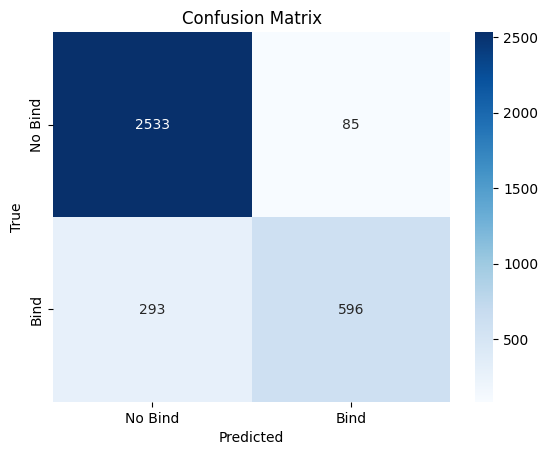

In [47]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Bind', 'Bind'], yticklabels=['No Bind', 'Bind'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

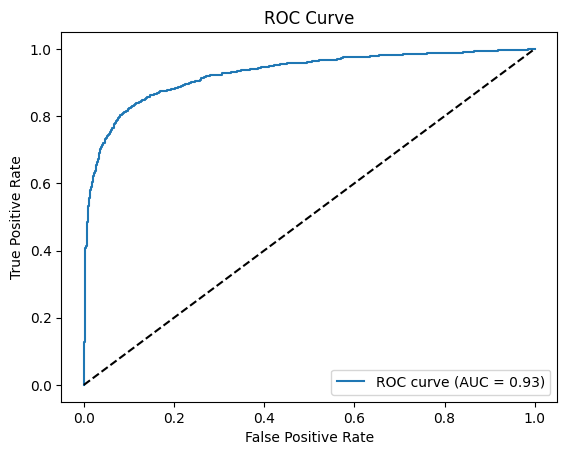

In [48]:
y_pred_proba = xgb_model.predict_proba(X_test.tolist())[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

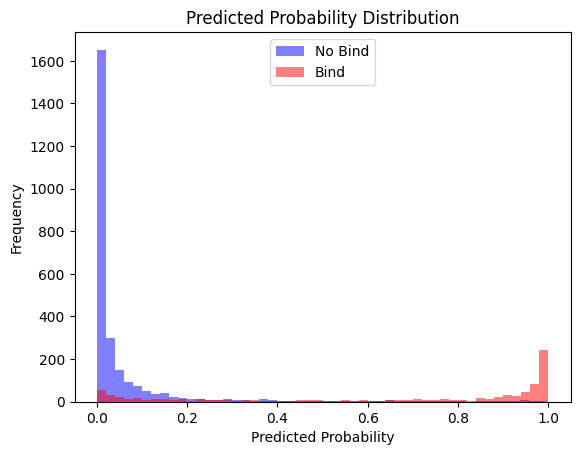

In [49]:
plt.figure()
plt.hist(y_pred_proba[y_test == 0], bins=50, alpha=0.5, label='No Bind', color='blue')
plt.hist(y_pred_proba[y_test == 1], bins=50, alpha=0.5, label='Bind', color='red')
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.title('Predicted Probability Distribution')
plt.legend(loc='upper center')
plt.show()

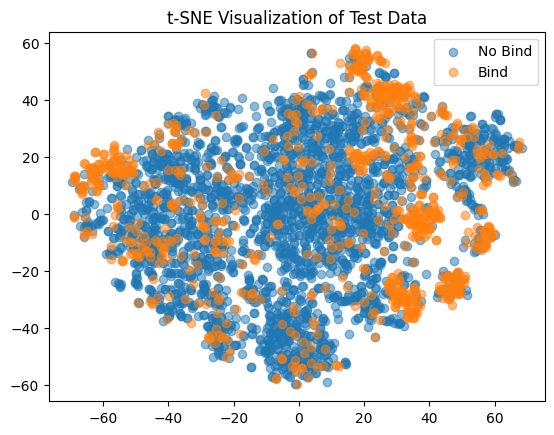

In [50]:
tsne = TSNE(n_components=2, random_state=42)
X_embedded = tsne.fit_transform(np.array(X_test.tolist()))

plt.figure()
plt.scatter(X_embedded[y_test == 0, 0], X_embedded[y_test == 0, 1], label='No Bind', alpha=0.5)
plt.scatter(X_embedded[y_test == 1, 0], X_embedded[y_test == 1, 1], label='Bind', alpha=0.5)
plt.title('t-SNE Visualization of Test Data')
plt.legend()
plt.show()

**all smiles information**

In [ ]:
balanced_data = spark.read.parquet("./intermediates/balanced_data")
data_subset = data.select("id", "buildingblock1_smiles", "buildingblock2_smiles", "buildingblock3_smiles", "molecule_smiles")

data_full = balanced_data.drop("kmeans_cluster").join(data_subset, on="id", how="left")
data_full.write.save("./intermediates/data_full", format="parquet", mode='overwrite')

In [67]:
tokenizer = AutoTokenizer.from_pretrained("seyonec/ChemBERTa-zinc-base-v1")
model = AutoModel.from_pretrained("seyonec/ChemBERTa-zinc-base-v1")


def smiles_embeddings(smiles:str):

    tokens = tokenizer(smiles, padding = True, truncation = True, max_length = 512, return_tensors = 'pt')
    
    with torch.no_grad():
        outputs = model(**tokens)
    
    return outputs.last_hidden_state.mean(dim = 1).squeeze().cpu().numpy().tolist()

balanced_data_with_embeddings = data_full.toPandas()

tqdm.pandas(desc="Generating Embeddings")

balanced_data_with_embeddings['buildingblock1_embedding'] = balanced_data_with_embeddings['buildingblock1_smiles'].progress_apply(smiles_embeddings)
balanced_data_with_embeddings['buildingblock2_embedding'] = balanced_data_with_embeddings['buildingblock2_smiles'].progress_apply(smiles_embeddings)
balanced_data_with_embeddings['buildingblock3_embedding'] = balanced_data_with_embeddings['buildingblock3_smiles'].progress_apply(smiles_embeddings)
balanced_data_with_embeddings['molecule_embedding'] = balanced_data_with_embeddings['molecule_smiles'].progress_apply(smiles_embeddings)

Generating Embeddings: 100%|██████████| 17533/17533 [14:05<00:00, 20.73it/s]


In [72]:
X = balanced_data_with_embeddings[['buildingblock1_embedding', 'buildingblock2_embedding', 'buildingblock3_embedding', 'molecule_embedding']]
y = balanced_data_with_embeddings['binds']


X = np.array(X.applymap(lambda x: np.array(x).tolist()).values.tolist())
X = np.array([np.concatenate(row) for row in X])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)  

y_pred = xgb_model.predict(X_test.tolist())
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}, F1: {f1:.4f}')

/tmp/ipykernel_193199/2071467526.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X = np.array(X.applymap(lambda x: np.array(x).tolist()).values.tolist())
/home/user/Desktop/Pharm/Medicine/BELKA/venv/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [10:17:39] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy: 0.9507, F1: 0.9009


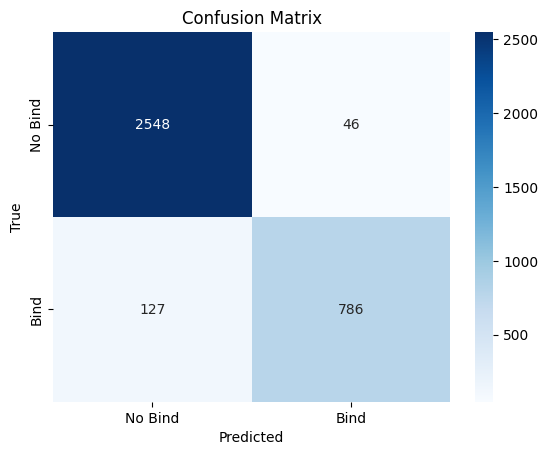

In [73]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Bind', 'Bind'], yticklabels=['No Bind', 'Bind'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

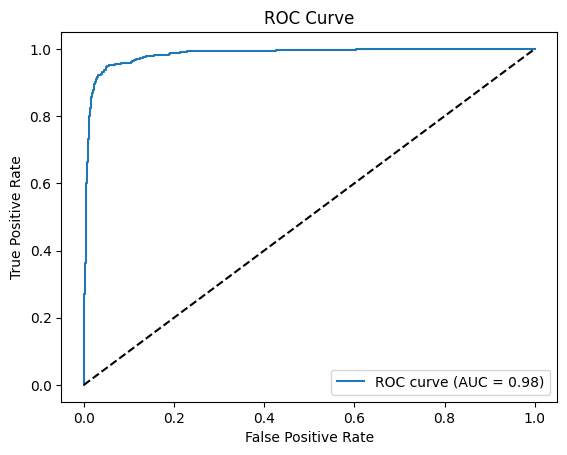

In [75]:
y_pred_proba = xgb_model.predict_proba(X_test.tolist())[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

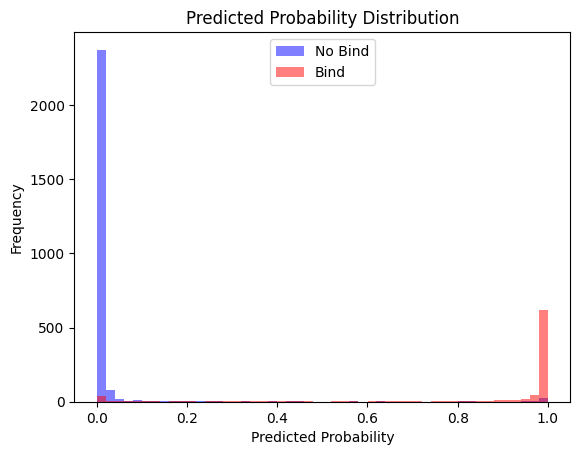

In [76]:
plt.figure()
plt.hist(y_pred_proba[y_test == 0], bins=50, alpha=0.5, label='No Bind', color='blue')
plt.hist(y_pred_proba[y_test == 1], bins=50, alpha=0.5, label='Bind', color='red')
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.title('Predicted Probability Distribution')
plt.legend(loc='upper center')
plt.show()

In [78]:
file_name = "xgb_cls.pkl"

pickle.dump(xgb_model, open(file_name, "wb"))

In [79]:
tokenizer = AutoTokenizer.from_pretrained("seyonec/ChemBERTa-zinc-base-v1")
model = AutoModel.from_pretrained("seyonec/ChemBERTa-zinc-base-v1")


def smiles_embeddings(smiles:str):

    tokens = tokenizer(smiles, padding = True, truncation = True, max_length = 512, return_tensors = 'pt')
    
    with torch.no_grad():
        outputs = model(**tokens)
    
    return outputs.last_hidden_state.mean(dim = 1).squeeze().cpu().numpy().tolist()

balanced_data_with_embeddings = data_full.toPandas()

tqdm.pandas(desc="Generating Embeddings")

balanced_data_with_embeddings['buildingblock1_embedding'] = balanced_data_with_embeddings['buildingblock1_smiles'].progress_apply(smiles_embeddings)
balanced_data_with_embeddings['buildingblock2_embedding'] = balanced_data_with_embeddings['buildingblock2_smiles'].progress_apply(smiles_embeddings)
balanced_data_with_embeddings['buildingblock3_embedding'] = balanced_data_with_embeddings['buildingblock3_smiles'].progress_apply(smiles_embeddings)

Generating Embeddings: 100%|██████████| 17533/17533 [08:20<00:00, 35.01it/s]


In [158]:
balanced_data_with_embeddings = balanced_data_with_embeddings.loc[balanced_data_with_embeddings.astype(str).drop_duplicates().index]

In [159]:
X = balanced_data_with_embeddings[['buildingblock1_embedding', 'buildingblock2_embedding', 'buildingblock3_embedding']]
y = balanced_data_with_embeddings['binds']


X = np.array(X.applymap(lambda x: np.array(x).tolist()).values.tolist())
X = np.array([np.concatenate(row) for row in X])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)  

y_pred = xgb_model.predict(X_test.tolist())
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}, F1: {f1:.4f}')

/tmp/ipykernel_193199/3988748382.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X = np.array(X.applymap(lambda x: np.array(x).tolist()).values.tolist())
/home/user/Desktop/Pharm/Medicine/BELKA/venv/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [18:42:32] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy: 0.9549, F1: 0.9091


In [23]:
data_full = spark.read.parquet('./intermediates/data_full')
df = data_full.toPandas()

#Downdsampling using 1 mln data (additional 400 k)

In [11]:
for i in range(4):
    
    data = data.filter(col("protein_name") == "sEH")

    counts = data.groupBy("binds").count().collect()
    counts_dict = {row['binds']: row['count'] for row in counts}

    count_binds_1 = counts_dict.get(1, 0)
    count_binds_0 = counts_dict.get(0, 0)

    total_counts = count_binds_1 + count_binds_0
    ratio_binds_0 = count_binds_1 / total_counts
    ratio_binds_1 = count_binds_1 / total_counts

    binds_1 = int(100000 * ratio_binds_1)
    binds_0 = 100000-binds_1

    binds_1_sampled = data.filter(col("binds") == 1).orderBy(rand()).limit(binds_1)
    binds_0_sampled = data.filter(col("binds") == 0).orderBy(rand()).limit(binds_0)

    sampled_data = binds_0_sampled.union(binds_1_sampled)

    sampled_data_with_desc = sampled_data.withColumn("molecule", calculate_desc(col("molecule_smiles")))
    sampled_data_with_desc = sampled_data_with_desc.withColumn("block1", calculate_desc(col("buildingblock1_smiles")))
    sampled_data_with_desc = sampled_data_with_desc.withColumn("block2", calculate_desc(col("buildingblock2_smiles")))
    sampled_data_with_desc = sampled_data_with_desc.withColumn("block3", calculate_desc(col("buildingblock3_smiles")))
    flattened_data = sampled_data_with_desc.select(*selected_columns)
    desc_columns = [col_name for col_name in flattened_data.columns if col_name != "id" and col_name != "binds"]

    assembler = VectorAssembler(inputCols=desc_columns, outputCol="features")
    sampled_data_with_features = assembler.transform(flattened_data).select("id", "binds", "features")

    scaler_model = StandardScalerModel.load("./intermediates/scaler_model")
    scaled_data = scaler_model.transform(sampled_data_with_features).select("id", "binds", "scaled_features")

    pca_model = PCAModel.load("./intermediates/pca_model")
    reduced_data = pca_model.transform(scaled_data).select("id", "binds", "pca_features")

    k_means_model = KMeansModel.load("./intermediates/k_means_model")
    new_kmeans_clusters = k_means_model.transform(reduced_data).select("id", "binds", "kmeans_cluster")

    all_clustered_data = all_clustered_data.union(new_kmeans_clusters)


In [ ]:
all_clustered_data.write.save("./intermediates/all_clustered_data", format="parquet", mode='overwrite')

In [ ]:
binds1 = all_clustered_data.filter(col("binds") == 1)
binds0 = all_clustered_data.filter(col("binds") == 0)

binds_1_counts = binds1.groupBy("kmeans_cluster").count().withColumnRenamed("count", "count_binds_1")
binds_0_counts = binds0.groupBy("kmeans_cluster").count().withColumnRenamed("count", "count_binds_0")


cluster_counts = binds_1_counts.join(binds_0_counts, "kmeans_cluster", "inner")

fractions_df = cluster_counts.withColumn("fraction", (F.col("count_binds_1") * 3) / F.col("count_binds_0"))

fractions = fractions_df.select("kmeans_cluster", "fraction").rdd.collectAsMap()

binds_0_sampled = binds0.sampleBy("kmeans_cluster", fractions, seed=42)

balanced_data = binds1.unionByName(binds_0_sampled.select(binds1.columns))

balanced_data.write.save("./intermediates/balanced_data", format="parquet", mode='overwrite')

balanced_data = spark.read.parquet("./intermediates/balanced_data")
data_subset = data.select("id", "buildingblock1_smiles", "buildingblock2_smiles", "buildingblock3_smiles", "molecule_smiles")

data_full = balanced_data.drop("kmeans_cluster").join(data_subset, on="id", how="left")
data_full.write.save("./intermediates/data_full", format="parquet", mode='overwrite')

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("seyonec/ChemBERTa-zinc-base-v1")
model = AutoModel.from_pretrained("seyonec/ChemBERTa-zinc-base-v1")


def smiles_embeddings(smiles:str):

    tokens = tokenizer(smiles, padding = True, truncation = True, max_length = 512, return_tensors = 'pt')
    
    with torch.no_grad():
        outputs = model(**tokens)
    
    return outputs.last_hidden_state.mean(dim = 1).squeeze().cpu().numpy().tolist()

balanced_data_with_embeddings = data_full.toPandas()

tqdm.pandas(desc="Generating Embeddings")

balanced_data_with_embeddings['buildingblock1_embedding'] = balanced_data_with_embeddings['buildingblock1_smiles'].progress_apply(smiles_embeddings)
balanced_data_with_embeddings['buildingblock2_embedding'] = balanced_data_with_embeddings['buildingblock2_smiles'].progress_apply(smiles_embeddings)
balanced_data_with_embeddings['buildingblock3_embedding'] = balanced_data_with_embeddings['buildingblock3_smiles'].progress_apply(smiles_embeddings)
balanced_data_with_embeddings['molecule_embedding'] = balanced_data_with_embeddings['molecule_smiles'].progress_apply(smiles_embeddings)

In [ ]:
balanced_data_with_embeddings = balanced_data_with_embeddings.loc[balanced_data_with_embeddings.astype(str).drop_duplicates().index]
balanced_data_with_embeddings.to_parquet('./leash-BELKA/data_with_embeddings.parquet')

**Experiment1**

WHETHER OUR MODEL WILL PERFORM GOOD ON UNSEEN DATA

In [13]:
balanced_data = spark.read.parquet('./intermediates/balanced_data')
balanced_data.printSchema()

root
 |-- id: long (nullable = true)
 |-- binds: long (nullable = true)
 |-- kmeans_cluster: integer (nullable = true)



In [14]:
filtered_data = data.filter(col("protein_name") == "sEH")

filtered_data = filtered_data.join(balanced_data, on="id", how="left_anti")

counts = filtered_data.groupBy("binds").count().collect()
counts_dict = {row['binds']: row['count'] for row in counts}

count_binds_1 = counts_dict.get(1, 0)
count_binds_0 = counts_dict.get(0, 0)

total_counts = count_binds_1 + count_binds_0
total_counts

98398085

In [15]:
ratio_binds_1 = count_binds_1 / total_counts
ratio_binds_0 = count_binds_0 / total_counts

binds_1 = int(100000 * ratio_binds_1)
binds_0 = 100000 - binds_1


binds_1_sampled = filtered_data.filter(col("binds") == 1).orderBy(rand()).limit(binds_1)

binds_0_sampled = filtered_data.filter(col("binds") == 0).orderBy(rand()).limit(binds_0)

sampled_data = binds_0_sampled.union(binds_1_sampled)

sampled_data.groupBy("binds").count().show()

+-----+-----+
|binds|count|
+-----+-----+
|    0|99269|
|    1|  731|
+-----+-----+



In [21]:
sampled_data_with_desc = sampled_data.withColumn("molecule", calculate_desc(col("molecule_smiles")))
sampled_data_with_desc = sampled_data_with_desc.withColumn("block1", calculate_desc(col("buildingblock1_smiles")))
sampled_data_with_desc = sampled_data_with_desc.withColumn("block2", calculate_desc(col("buildingblock2_smiles")))
sampled_data_with_desc = sampled_data_with_desc.withColumn("block3", calculate_desc(col("buildingblock3_smiles")))
flattened_data = sampled_data_with_desc.select(*selected_columns)
desc_columns = [col_name for col_name in flattened_data.columns if col_name != "id" and col_name != "binds"]

assembler = VectorAssembler(inputCols=desc_columns, outputCol="features")
sampled_data_with_features = assembler.transform(flattened_data).select("id", "binds", "features")

scaler_model = StandardScalerModel.load("./intermediates/scaler_model")
scaled_data = scaler_model.transform(sampled_data_with_features).select("id", "binds", "scaled_features")

pca_model = PCAModel.load("./intermediates/pca_model")
reduced_data = pca_model.transform(scaled_data).select("id", "binds", "pca_features")

k_means_model = KMeansModel.load("./intermediates/k_means_model")
new_kmeans_clusters = k_means_model.transform(reduced_data).select("id", "binds", "kmeans_cluster")

In [22]:
binds1 = new_kmeans_clusters.filter(col("binds") == 1)
binds0 = new_kmeans_clusters.filter(col("binds") == 0)

binds_1_counts = binds1.groupBy("kmeans_cluster").count().withColumnRenamed("count", "count_binds_1")
binds_0_counts = binds0.groupBy("kmeans_cluster").count().withColumnRenamed("count", "count_binds_0")


cluster_counts = binds_1_counts.join(binds_0_counts, "kmeans_cluster", "inner")

fractions_df = cluster_counts.withColumn("fraction", (F.col("count_binds_1") * 3) / F.col("count_binds_0"))

fractions = fractions_df.select("kmeans_cluster", "fraction").rdd.collectAsMap()

binds_0_sampled = binds0.sampleBy("kmeans_cluster", fractions, seed=42)

balanced_data = binds1.unionByName(binds_0_sampled.select(binds1.columns))

balanced_data = spark.read.parquet("./intermediates/balanced_data")
data_subset = data.select("id", "buildingblock1_smiles", "buildingblock2_smiles", "buildingblock3_smiles")

data_full = balanced_data.drop("kmeans_cluster").join(data_subset, on="id", how="left")

In [32]:
data_subset = data.select("id", "buildingblock1_smiles", "buildingblock2_smiles", "buildingblock3_smiles", "molecule_smiles")

data_full = balanced_data.drop("kmeans_cluster").join(data_subset, on="id", how="left")
data_full.write.save("./intermediates/testing_new", format="parquet", mode='overwrite')

#Take data that have been already balanced 


In [514]:
train_data = spark.read.parquet('./intermediates/data_full')
train_data = train_data.toPandas()

In [515]:
train_data = train_data[~train_data.duplicated()]

In [516]:
fpg = rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=700, useBondTypes=True, includeChirality=True, includeRingMembership=True)

def compute_fn(smiles):
    
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(2048, dtype=np.int8)
    
    ao = rdFingerprintGenerator.AdditionalOutput()
    ao.AllocateBitInfoMap()
    
    
    fp = fpg.GetCountFingerprint(mol, additionalOutput=ao)

    bit_info = ao.GetBitInfoMap()
    arr = np.zeros(2048, dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp, arr)
   
    return arr, bit_info


In [517]:
results = train_data['molecule_smiles'].apply(compute_fn)
train_data['fp'] = results.apply(lambda x: x[0])
bit_infos = results.apply(lambda x: x[1]).tolist()
train_data.drop(['molecule_smiles', "buildingblock1_smiles", "buildingblock2_smiles", "buildingblock3_smiles"], axis=1, inplace=True)
fingerprint_df = pd.DataFrame(train_data["fp"].to_list(), index=train_data.index)
train_data = pd.concat([train_data.drop(columns=["fp"]), fingerprint_df], axis=1)

In [518]:
feature_cols = [col for col in train_data.columns if col not in ['id', 'binds']]

X = train_data[feature_cols]
y = train_data['binds']


In [519]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [520]:
lgb_cls = LGBMClassifier()
lgb_cls.fit(X_train, y_train)

y_pred = lgb_cls.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}, F1: {f1:.4f}')

[LightGBM] [Info] Number of positive: 3527, number of negative: 10493
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.028807 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2884
[LightGBM] [Info] Number of data points in the train set: 14020, number of used features: 700
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.251569 -> initscore=-1.090261
[LightGBM] [Info] Start training from score -1.090261
Accuracy: 0.9512, F1: 0.9005


In [521]:
data_check = pd.read_parquet('./intermediates/testing_new')
y_true = data_check['binds']

In [522]:
results = data_check['molecule_smiles'].apply(compute_fn)
data_check['fp'] = results.apply(lambda x: x[0])
bit_infos = results.apply(lambda x: x[1]).tolist()
data_check.drop(['molecule_smiles', "buildingblock1_smiles", "buildingblock2_smiles", "buildingblock3_smiles"], axis=1, inplace=True)
fingerprint_df = pd.DataFrame(data_check["fp"].to_list(), index=data_check.index)
data_check = pd.concat([data_check.drop(columns=["fp"]), fingerprint_df], axis=1)

In [ ]:
results = data_check['molecule_smiles'].apply(compute_fn)
data_check['fp'] = results.apply(lambda x: x[0])
bit_infos = results.apply(lambda x: x[1]).tolist()
data_check.drop(['molecule_smiles', "buildingblock1_smiles", "buildingblock2_smiles", "buildingblock3_smiles"], axis=1, inplace=True)
fingerprint_df = pd.DataFrame(data_check["fp"].to_list(), index=data_check.index)
data_check = pd.concat([data_check.drop(columns=["fp"]), fingerprint_df], axis=1)

In [525]:
feature_cols = [col for col in data_check.columns if col not in ['id', 'binds']]

X = data_check[feature_cols]
y_true = data_check['binds']


y_pred = lgb_cls.predict(X)
accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
print(f'Accuracy: {accuracy:.4f}, F1: {f1:.4f}')


Accuracy: 0.9793, F1: 0.9586


In [534]:
file_name = "lightgbm_cls.pkl"

pickle.dump(lgb_cls, open(file_name, "wb"))

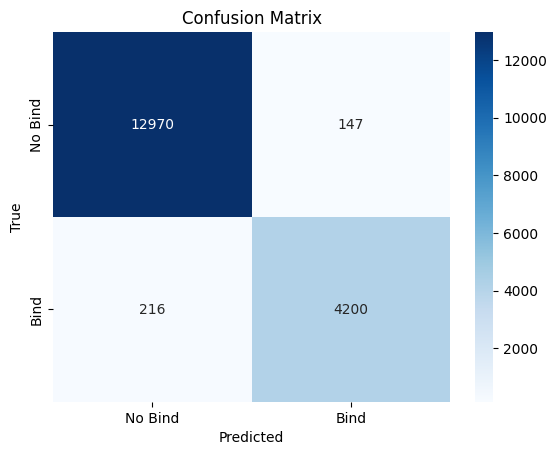

In [528]:
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Bind', 'Bind'], yticklabels=['No Bind', 'Bind'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [529]:
data_check = pd.read_parquet('./intermediates/testing_new')

In [530]:
data_check['protein_name'] = 'sEH'

In [536]:
predictor = Prediction(data_check.drop('binds', axis = 1))
y_pred, X, bit_infos = predictor.predict()

/home/user/Desktop/Pharm/Medicine/BELKA/functions.py:129: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  self.data = pd.concat([self.data.drop(columns=["fp"]), fingerprint_df], axis=1)


**VIZUALIZATION**

In [538]:
#feature importance

feature_names = [f"{i}" for i in range(700)]

importance = lightgbm_cls.feature_importances_
importance_df = pd.DataFrame({'bit': feature_names, 'importance': importance})
importance_df = importance_df.sort_values(by = 'importance', ascending=False)

In [539]:
importance_df.head()

,bit,importance
683,683,55
217,217,39
559,559,37
395,395,32
402,402,32


In [541]:
top_bits = set(int(bit) for bit in importance_df.head(30)['bit'].values)

In [559]:
#Bit count for each class
bit_counts = {0: Counter(), 1: Counter()}

for pred, bits in zip(y_pred, bit_infos):
    filtered_bits = {bit:atom for bit, atom in bits.items()}
    bit_counts[pred].update(filtered_bits.keys())

#Because of the overlap of bits we will take wider range to exctract 5 unique
most_common_0 = bit_counts[0].most_common(30) 
most_common_1 = bit_counts[1].most_common(30)

bits_0 = {bit for bit, _ in most_common_0}
bits_1 = {bit for bit, _ in most_common_1}

unique_0 = [bit for bit, _ in most_common_0 if bit not in bits_1][:5]
unique_1 = [bit for bit, _ in most_common_1 if bit not in bits_0][:5]

print("5 Unique Most Frequent Bits in Class 0:", unique_0)
print("5 Unique Most Frequent Bits in Class 1:", unique_1)

5 Unique Most Frequent Bits in Class 0: [699, 184, 474, 149, 501]
5 Unique Most Frequent Bits in Class 1: [587, 662, 533, 677, 554]


In [553]:
class_0_indices = [i for i, pred in enumerate(y_pred) if pred == 0]
class_1_indices = [i for i, pred in enumerate(y_pred) if pred == 1]

# Pick a random sample from each class
random_sample_class_0_idx = random.choice(class_0_indices)
random_sample_class_1_idx = random.choice(class_1_indices)

In [578]:
#Get corresponding molecules
mol_class_0 = Chem.MolFromSmiles(data_check.loc[random_sample_class_0_idx, 'molecule_smiles'])
mol_class_1 = Chem.MolFromSmiles(data_check.loc[random_sample_class_1_idx, 'molecule_smiles'])

#Get the bit information for these molecules and filter for unique bits
filtered_bit_info_class_0 = {bit: bit_infos[random_sample_class_0_idx][bit] for bit in bit_infos[random_sample_class_0_idx] if bit in unique_0}
filtered_bit_info_class_1 = {bit: bit_infos[random_sample_class_1_idx][bit] for bit in bit_infos[random_sample_class_1_idx] if bit in unique_1}

In [577]:
def get_bit_highlights(mol, atom_idx, radius):
    """
    Get atoms and bonds involved in a Morgan fingerprint bit.
    """
    env = Chem.FindAtomEnvironmentOfRadiusN(mol, radius, atom_idx)
    atoms = {atom_idx}
    for bond_idx in env:
        bond = mol.GetBondWithIdx(bond_idx)
        atoms.update([bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()])
    bonds = {bond.GetIdx() for atom_idx in atoms for bond in mol.GetAtomWithIdx(atom_idx).GetBonds()}
    return atoms, bonds

def plot_bit_features(mol, bit_info, bit_idx, **draw_kwargs):
    """
    Plot the substructures corresponding to a specific bit.
    """
    bit_tuples = bit_info[bit_idx]
    plot_mols = []
    atom_highlights = []
    bond_highlights = []

    for atom_idx, radius in bit_tuples:
        bit_atoms, bit_bonds = get_bit_highlights(mol, atom_idx, radius)
        atom_highlights.append(list(bit_atoms))
        bond_highlights.append(list(bit_bonds))
        plot_mols.append(mol)

    img = Draw.MolsToGridImage(plot_mols,
                               highlightAtomLists=atom_highlights,
                               highlightBondLists=bond_highlights,
                               **draw_kwargs)
    return img

*Vizualization for class 0 important bits with their atoms and bonds*

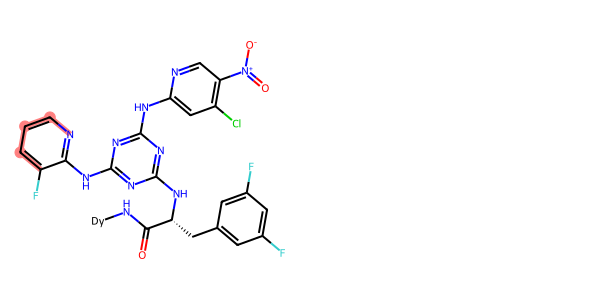

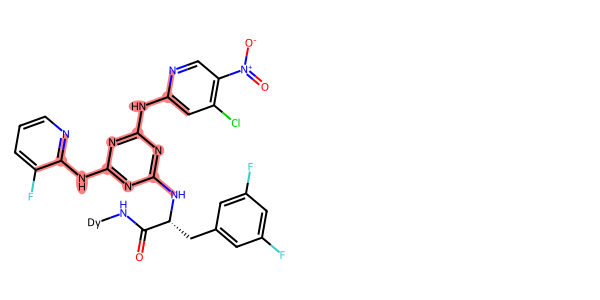

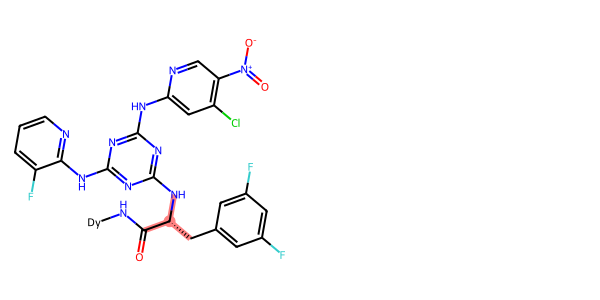

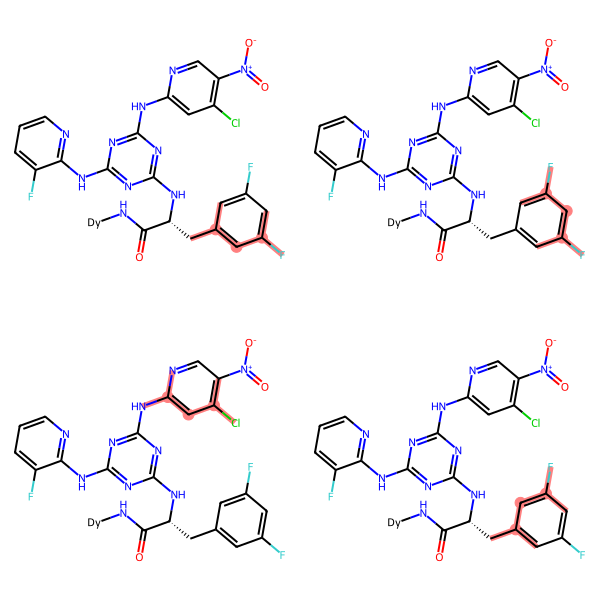

In [586]:
for bit_idx, bit_tuples in filtered_bit_info_class_0.items():
    img_class_0 = plot_bit_features(
        mol_class_0, 
        {bit_idx: bit_tuples},
        bit_idx=bit_idx, 
        molsPerRow=2,     
        subImgSize=(300, 300) 
    )
    display(img_class_0)

*Vizualization for class 1 important bits with their atoms and bonds*

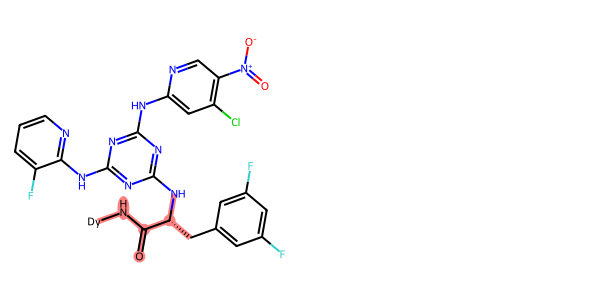

In [587]:
for bit_idx, bit_tuples in filtered_bit_info_class_1.items():
    img_class_1 = plot_bit_features(
        mol_class_0, 
        {bit_idx: bit_tuples},
        bit_idx=bit_idx, 
        molsPerRow=2,     
        subImgSize=(300, 300) 
    )
    display(img_class_1)

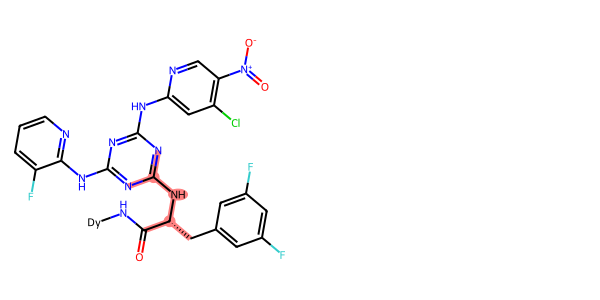

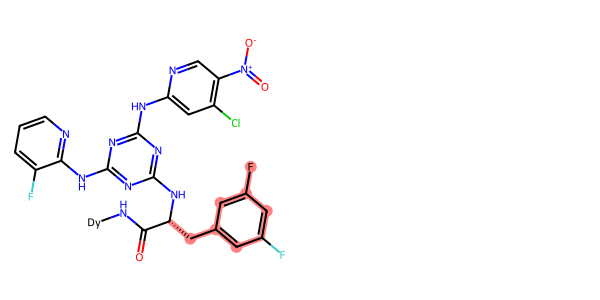

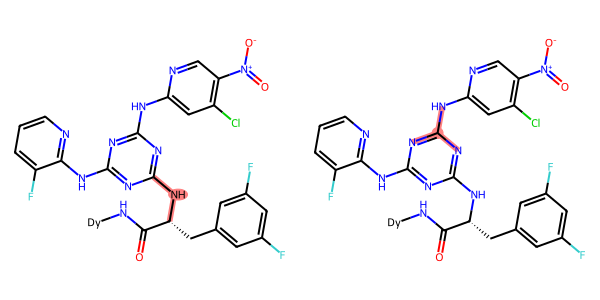

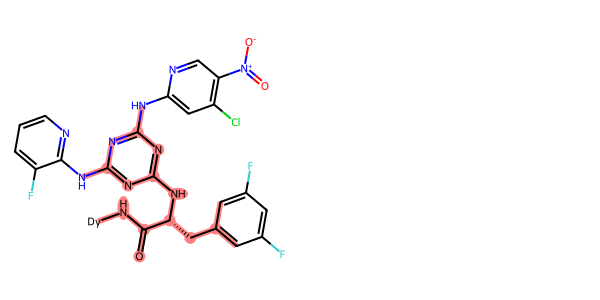

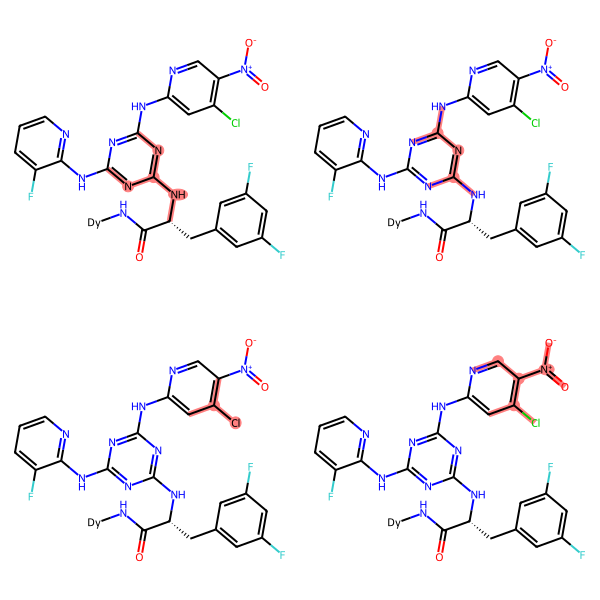

In [588]:
#Get corresponding molecules
random_sample_class_1_idx = random.choice(class_1_indices)
mol_class_1 = Chem.MolFromSmiles(data_check.loc[random_sample_class_1_idx, 'molecule_smiles'])
filtered_bit_info_class_1 = {bit: bit_infos[random_sample_class_1_idx][bit] for bit in bit_infos[random_sample_class_1_idx] if bit in unique_1}

for bit_idx, bit_tuples in filtered_bit_info_class_1.items():
    img_class_1 = plot_bit_features(
        mol_class_0, 
        {bit_idx: bit_tuples},
        bit_idx=bit_idx, 
        molsPerRow=2,     
        subImgSize=(300, 300) 
    )
    display(img_class_1)

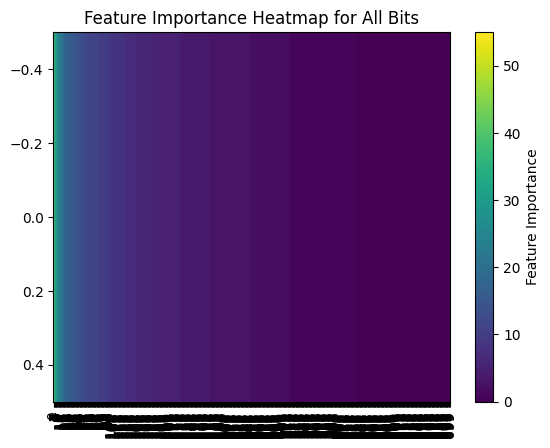

In [543]:
# Assuming the full feature importance is stored in importance_df
importance_matrix = importance_df.set_index('bit')['importance'].values
importance_matrix = importance_matrix.reshape(1, -1)  # Reshape to 1 row matrix for heatmap
plt.imshow(importance_matrix, cmap='viridis', aspect='auto')
plt.colorbar(label='Feature Importance')
plt.xticks(np.arange(len(feature_names)), feature_names, rotation=90)
plt.title('Feature Importance Heatmap for All Bits')
plt.show()


*MODEL CHECK*

In [590]:
data = data.filter(col("protein_name") == "sEH")
sampled_data = data.orderBy(rand()).limit(10000)

In [592]:
predictor = Prediction(sampled_data.toPandas().drop('binds', axis = 1))
y_pred, X, bit_infos = predictor.predict()

/home/user/Desktop/Pharm/Medicine/BELKA/functions.py:129: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  self.data = pd.concat([self.data.drop(columns=["fp"]), fingerprint_df], axis=1)


In [595]:
y_true = sampled_data.toPandas()['binds']
accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
print(f'Accuracy: {accuracy:.4f}, F1: {f1:.4f}')


Accuracy: 0.9794, F1: 0.3720


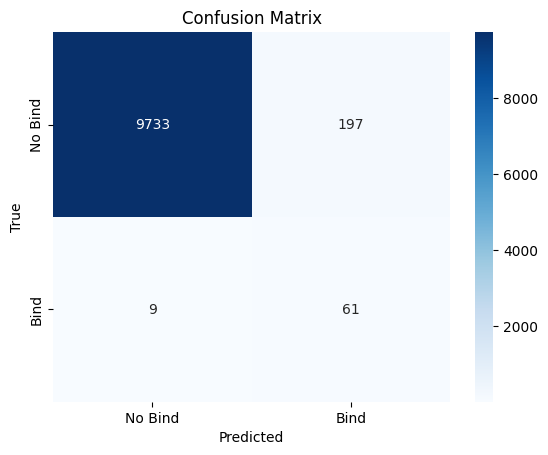

In [596]:
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Bind', 'Bind'], yticklabels=['No Bind', 'Bind'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

**1 million data with 1 descriptor on 2 blocks"

In [597]:
data = data.filter(col("protein_name") == "sEH")

counts = data.groupBy("binds").count().collect()
counts_dict = {row['binds']: row['count'] for row in counts}

count_binds_1 = counts_dict.get(1, 0)
count_binds_0 = counts_dict.get(0, 0)

total_counts = count_binds_1 + count_binds_0
ratio_binds_0 = count_binds_1 / total_counts
ratio_binds_1 = count_binds_1 / total_counts

binds_1 = int(1000000 * ratio_binds_1)
binds_0 = 1000000-binds_1

binds_1_sampled = data.filter(col("binds") == 1).orderBy(rand()).limit(binds_1)
binds_0_sampled = data.filter(col("binds") == 0).orderBy(rand()).limit(binds_0)

sampled_data = binds_0_sampled.union(binds_1_sampled)

sampled_data.groupBy("binds").count().show()

+-----+------+
|binds| count|
+-----+------+
|    0|992639|
|    1|  7361|
+-----+------+



In [599]:
desc_schema = StructType([
    StructField("mol_wt", DoubleType(), True)
]
)

@pandas_udf(desc_schema)
def calculate_desc(smiles_series: pd.Series) -> pd.DataFrame:

    mols = smiles_series.apply(Chem.MolFromSmiles)
    
    mw = mols.apply(lambda mol: round(Descriptors.MolWt(mol), 3) if mol else None)


    return pd.DataFrame({'mol_wt': mw})
    
sampled_data_with_desc = sampled_data_with_desc.withColumn("block1", calculate_desc(col("buildingblock1_smiles")))
sampled_data_with_desc = sampled_data_with_desc.withColumn("block3", calculate_desc(col("buildingblock3_smiles")))

In [600]:
selected_columns = [
    "id",
    col("block1.mol_wt").alias("block1_mol_wt"),
    col("block3.mol_wt").alias("block3_mol_wt"),
    "binds"
]

flattened_data = sampled_data_with_desc.select(*selected_columns)

desc_columns = [col_name for col_name in flattened_data.columns if col_name != "id" and col_name != "binds"]

assembler = VectorAssembler(inputCols=desc_columns, outputCol="features")
sampled_data_with_features = assembler.transform(flattened_data).select("id", "binds", "features")

In [601]:
kmeans = KMeans(k = 30, seed = 42, maxIter = 10, featuresCol = 'features', predictionCol = 'kmeans_cluster')
k_means_model = kmeans.fit(sampled_data_with_features)
kmeans_clusters = k_means_model.transform(sampled_data_with_features).select("id", "binds", "kmeans_cluster")

In [602]:
k_means_model.write().overwrite().save("./intermediates/k_means_model_1_mln")
kmeans_clusters.write.save("./intermediates/kmeans_clusters_1_mln", format="parquet", mode='overwrite')

In [603]:
binds1 = kmeans_clusters.filter(col("binds") == 1)
binds0 = kmeans_clusters.filter(col("binds") == 0)
binds_1_counts = binds1.groupBy("kmeans_cluster").count().withColumnRenamed("count", "count_binds_1")
binds_0_counts = binds0.groupBy("kmeans_cluster").count().withColumnRenamed("count", "count_binds_0")


cluster_counts = binds_1_counts.join(binds_0_counts, "kmeans_cluster", "inner")

fractions_df = cluster_counts.withColumn("fraction", (F.col("count_binds_1") * 3) / F.col("count_binds_0"))

fractions = fractions_df.select("kmeans_cluster", "fraction").rdd.collectAsMap()

binds_0_sampled = binds0.sampleBy("kmeans_cluster", fractions, seed=42)

balanced_data = binds1.unionByName(binds_0_sampled.select(binds1.columns))

balanced_data.write.save("./intermediates/balanced_data_1_mln", format="parquet", mode='overwrite')

In [604]:
data_subset = data.select("id", "molecule_smiles")

final_data = balanced_data.drop("kmeans_cluster").join(data_subset, on="id", how="left")
final_data.write.save("./intermediates/final_data_1_mln", format="parquet", mode='overwrite')

In [607]:
final_data = spark.read.parquet("./intermediates/final_data_1_mln")

In [617]:
final_data.shape

(29425, 702)

In [620]:
final_data.dtypes

id       int64
binds    int64
0         int8
1         int8
2         int8
         ...  
695       int8
696       int8
697       int8
698       int8
699       int8
Length: 702, dtype: object

In [608]:
final_data = final_data.toPandas()

fpg = rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=700, useBondTypes=True, includeChirality=True, includeRingMembership=True)

def compute_fn(smiles):
    
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(2048, dtype=np.int8)
    
    ao = rdFingerprintGenerator.AdditionalOutput()
    ao.AllocateBitInfoMap()
    
    
    fp = fpg.GetCountFingerprint(mol, additionalOutput=ao)

    bit_info = ao.GetBitInfoMap()
    arr = np.zeros(2048, dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp, arr)
   
    return arr, bit_info

results = final_data['molecule_smiles'].apply(compute_fn)
final_data['fp'] = results.apply(lambda x: x[0])
bit_infos = results.apply(lambda x: x[1]).tolist()
final_data.drop(['molecule_smiles'], axis=1, inplace=True)
fingerprint_df = pd.DataFrame(final_data["fp"].to_list(), index=final_data.index)
final_data = pd.concat([final_data.drop(columns=["fp"]), fingerprint_df], axis=1)

feature_cols = [col for col in final_data.columns if col not in ['id', 'binds']]

X = final_data[feature_cols]
y = final_data['binds']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

lgb_cls = LGBMClassifier()
lgb_cls.fit(X_train, y_train)

y_pred = lgb_cls.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}, F1: {f1:.4f}')


[LightGBM] [Info] Number of positive: 5889, number of negative: 17651
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.034588 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2974
[LightGBM] [Info] Number of data points in the train set: 23540, number of used features: 700
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.250170 -> initscore=-1.097706
[LightGBM] [Info] Start training from score -1.097706
Accuracy: 0.9545, F1: 0.9073


In [609]:
data = data.filter(col("protein_name") == "sEH")
sampled_data = data.orderBy(rand()).limit(10000)

In [611]:
feature_cols = [col for col in final_data.columns if col not in ['id', 'binds']]

X = final_data[feature_cols]
y = final_data['binds']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [614]:
y_pred = lgb_cls.predict(X)
accuracy = accuracy_score(y, y_pred)
f1 = f1_score(y, y_pred)
print(f'Accuracy: {accuracy:.4f}, F1: {f1:.4f}')

Accuracy: 0.9719, F1: 0.9436


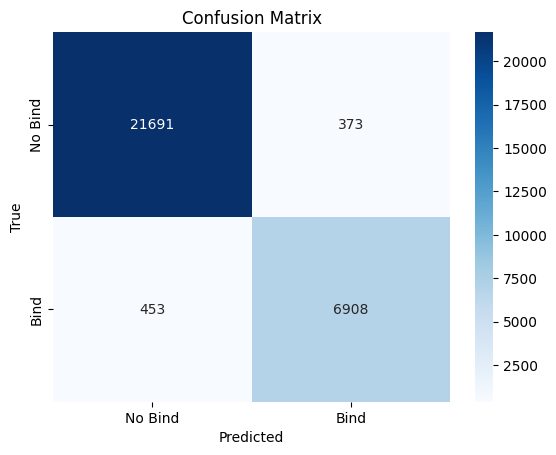

In [615]:
cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Bind', 'Bind'], yticklabels=['No Bind', 'Bind'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [621]:
file_name = "lightgbm_cls.pkl"

pickle.dump(lgb_cls, open(file_name, "wb"))

In [622]:
filtered_data = data.filter(F.col("protein_name") == "sEH")
filtered_data = filtered_data.join(balanced_data, on="id", how="left_anti")

binds_0_sampled = filtered_data.filter(F.col("binds") == 0).orderBy(F.rand()).limit(20000)
binds_1_sampled = filtered_data.filter(F.col("binds") == 1).orderBy(F.rand()).limit(2000)

sampled_data = binds_0_sampled.union(binds_1_sampled)


sampled_data.groupBy("binds").count().show()

+-----+-----+
|binds|count|
+-----+-----+
|    0|20000|
|    1| 2000|
+-----+-----+



In [ ]:
sampled_data = sampled_data.toPandas()
results = sampled_data['molecule_smiles'].apply(compute_fn)
sampled_data['fp'] = results.apply(lambda x: x[0])
bit_infos = results.apply(lambda x: x[1]).tolist()
sampled_data.drop(['molecule_smiles', "buildingblock1_smiles", "buildingblock2_smiles", "buildingblock3_smiles"], axis=1, inplace=True)
fingerprint_df = pd.DataFrame(sampled_data["fp"].to_list(), index=sampled_data.index)
sampled_data = pd.concat([sampled_data.drop(columns=["fp"]), fingerprint_df], axis=1)


In [626]:
feature_cols = [col for col in sampled_data.columns if col not in ['id', 'binds', 'protein_name']]

X = sampled_data[feature_cols]
y_true = sampled_data['binds']


y_pred = lgb_cls.predict(X)
accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
print(f'Accuracy: {accuracy:.4f}, F1: {f1:.4f}')

Accuracy: 0.9710, F1: 0.8497


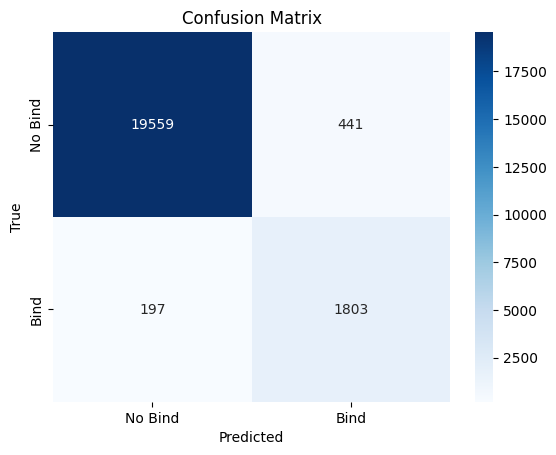

In [627]:
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Bind', 'Bind'], yticklabels=['No Bind', 'Bind'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()